### Import Libraries

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt
import seaborn as sns; sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

### Load Training and Testing Sets

In [11]:
# load scaled data sets for Linear Model
train_set = pd.read_csv('data/model_sets/train_set_scaled.csv')
test_set = pd.read_csv('data/model_sets/test_set_scaled.csv')

# training
X_train = train_set.drop(columns=['logClosePrice'])
y_train = train_set['logClosePrice']

# testing
X_test = test_set.drop(columns=['logClosePrice'])
y_test = test_set['logClosePrice']

In [12]:
train_set.columns

Index(['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'Latitude',
       'Longitude', 'LivingArea', 'CountyOrParish', 'AttachedGarageYN',
       'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'FireplaceYN', 'Stories', 'Levels',
       'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'logClosePrice'],
      dtype='object')

### Cross Validation

In [13]:
model = LinearRegression()

# cross validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print(f'CV R^2 scores: {np.round(cv_scores, 4)}')
print(f'Mean CV R^2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

CV R^2 scores: [0.7853 0.8177 0.8051 0.7596 0.7885]
Mean CV R^2: 0.7912 (+/- 0.0197)


### Run Model

In [14]:
# fit model on training data only
model.fit(X_train, y_train)

# generate predictions on test set
preds = model.predict(X_test)

# evaluate performance
r2 = r2_score(y_test, preds)
print(f'R^2 score: {round(r2, 4)}')

R^2 score: 0.7812


### Visualizations

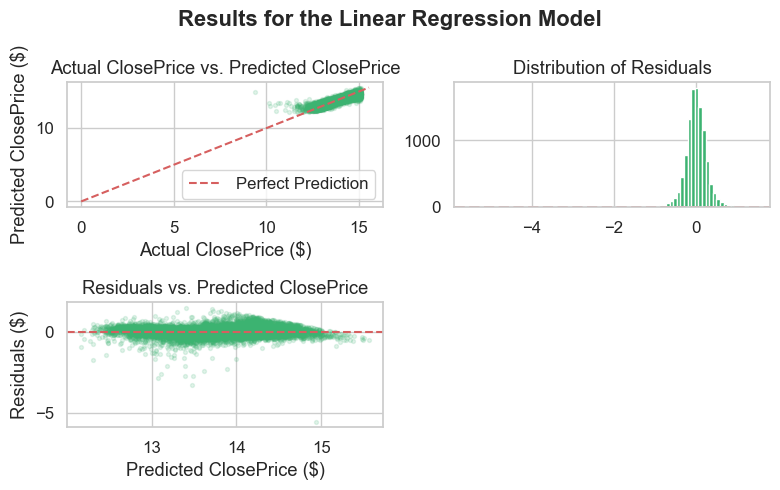

In [15]:
fig, axes = plt.subplots(2,2, figsize=(8,5))
fig.suptitle('Results for the Linear Regression Model', fontweight = 'bold')

# actual vs predicted scatter plot
axes[0,0].scatter(y_test, preds, alpha=0.15, s=8, color='mediumseagreen')
axes[0,0].plot([0, max(y_test.max(), preds.max())], [0, max(y_test.max(), preds.max())], 
               color='r', ls = '--', label = 'Perfect Prediction')
axes[0,0].set_xlabel('Actual ClosePrice ($)')
axes[0,0].set_ylabel('Predicted ClosePrice ($)')
axes[0,0].set_title('Actual ClosePrice vs. Predicted ClosePrice')
axes[0,0].legend()

# distribution of residuals
residuals = y_test - preds
axes[0,1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Residuals')
axes[0,1].axhline(0, color='r', ls='--', lw=2)

# Residuals vs Predicted ClosePrice
axes[1,0].scatter(preds, residuals, color='mediumseagreen', alpha=0.15, s=8)
axes[1,0].axhline(0, color='r', ls='--')
axes[1,0].set_title('Residuals vs. Predicted ClosePrice')
axes[1,0].set_xlabel('Predicted ClosePrice ($)')
axes[1,0].set_ylabel('Residuals ($)')

# set final quadrant to be invisible for aesthetics
axes[1,1].set_visible(False)

plt.tight_layout(); plt.show()